# Project 4 — The Weirdest NBA Games of the Season

## The mystery we're solving

Every NBA season has nights people remember forever. Giannis dropping 59 against Detroit. Wembanyama getting 42 points with 4 blocks and 7 threes. A guard recording a triple-double. A bench player going 0-for-15.

These games are **statistically unusual** — the box score looks nothing like a typical NBA night. Could an algorithm find them on its own, **without anyone telling it which games were special**?

That's the goal of **anomaly detection** — and it's the same family of techniques real companies use to:
- Catch credit-card fraud (a transaction that looks nothing like your usual spending)
- Detect faulty sensors (a reading way off normal)
- Flag intrusion attempts (login behaviour that doesn't match anyone's pattern)

We'll point the same tools at NBA box scores and see what stands out.

## What we'll do, in plain English

1. Filter to games where the player actually played meaningful minutes.
2. Scale the box-score features.
3. Run two different anomaly-detection algorithms — **Isolation Forest** and **Local Outlier Factor**.
4. Print the top-20 weirdest games each one finds.
5. Explain *why* each game was flagged (which stats were extreme).
6. Compare the two algorithms — where do they agree?
7. Visualise the whole thing in PCA space.

## What you'll learn

- What an **anomaly** is in machine-learning terms.
- How **Isolation Forest** works (the "easy-to-isolate = weird" intuition).
- How **LOF** works (a different definition: "low-density = weird").
- Why **two different anomaly methods** can both be useful — they catch different kinds of weirdness.
- How to **interpret** an anomaly score with z-scores so a human can understand "weird how?"

> **Heads-up:** this notebook builds on [Project 0 (EDA)](00_eda.ipynb) — and is the second of our two unsupervised-learning projects (the other is [Project 3 — clustering](03_player_archetypes_clustering.ipynb)).


## 1. Setup

Two new scikit-learn tools:
- **`IsolationForest`** — finds points that are easy to "isolate" with random splits.
- **`LocalOutlierFactor`** (LOF) — finds points whose local neighbourhood is much sparser than typical.

We also use `StandardScaler` and `PCA` from earlier projects.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
RANDOM_STATE = 42

## 2. Load and filter the data

### Why filter to MP >= 15?

If we let in every player-game, including 1-minute garbage-time appearances, the algorithm would flag a flood of "anomalies" that are just stat-lines full of zeros (because the player didn't play long enough to do anything). Those aren't interesting.

By filtering to **at least 15 minutes**, we keep only meaningful appearances and let the algorithm focus on stat-lines that actually represent how a player performed.


In [2]:
DATA_PATH = "../data/nbadatabase_24_25 2/nbadatabase_24_25.csv"
df = pd.read_csv(DATA_PATH)
df["Data"] = pd.to_datetime(df["Data"])

print(f"Total player-games: {len(df):,}")
df = df[df["MP"] >= 15].reset_index(drop=True)
print(f"After MP ≥ 15 filter: {len(df):,}")
df.head()

Total player-games: 16,512
After MP ≥ 15 filter: 12,151


,Player,Tm,Opp,Res,MP,FG,FGA,FG%,3P,3PA,3P%,FT,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,GmSc,Data
0,Jayson Tatum,BOS,NYK,W,30.30,14,18,0.778,8,11,0.727,1,2,0.500,0,4,4,10,1,1,1,1,37,38.1,2024-10-22
1,Anthony Davis,LAL,MIN,W,37.58,11,23,0.478,1,3,0.333,13,15,0.867,3,13,16,4,1,3,1,1,36,34.0,2024-10-22
2,Derrick White,BOS,NYK,W,26.63,8,13,0.615,6,10,0.600,2,2,1.000,0,3,3,4,1,0,0,1,24,22.4,2024-10-22
3,Jrue Holiday,BOS,NYK,W,30.52,7,9,0.778,4,6,0.667,0,0,0.000,2,2,4,4,1,0,0,2,18,19.5,2024-10-22
4,Miles McBride,NYK,BOS,L,25.85,8,10,0.800,4,5,0.800,2,3,0.667,0,0,0,2,0,0,1,1,22,17.8,2024-10-22


## 3. Pick features and scale them

### Which features?

We use the raw **counting stats** — minutes, makes, attempts, rebounds, assists, steals, blocks, turnovers, fouls, points. We skip the percentages because they're undefined when a player didn't attempt that shot type (and we can't have NaNs feeding into the model).

### Why scaling matters

Both Isolation Forest and LOF are influenced by feature scale. Without scaling, large-magnitude features like `MP` (range 0-50) would dominate small-magnitude ones like `BLK` (range 0-10). After scaling, every feature contributes equally to "weirdness".

> **What we just learned:** the same scaling step we used in Project 3 (clustering) is needed here too. Anything based on distance or density needs scaled features.


In [3]:
feature_cols = ["MP", "FG", "FGA", "3P", "3PA", "FT", "FTA",
                "ORB", "DRB", "AST", "STL", "BLK", "TOV", "PF", "PTS"]

X = df[feature_cols].fillna(0).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pd.DataFrame(X_scaled, columns=feature_cols).describe().round(2).loc[["mean", "std", "min", "max"]]

,MP,FG,FGA,3P,3PA,FT,FTA,ORB,DRB,AST,STL,BLK,TOV,PF,PTS
mean,-0.00,-0.00,0.00,0.00,-0.00,0.00,0.00,0.00,-0.00,-0.00,-0.00,0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.78,-1.56,-1.86,-0.99,-1.38,-0.83,-0.89,-0.84,-1.39,-1.14,-0.91,-0.63,-1.05,-1.47,-1.58
max,3.21,5.46,4.93,5.24,4.95,6.63,8.13,7.35,7.03,6.97,6.71,10.38,6.29,2.78,5.50


## 4. Isolation Forest — the intuition

### How does it work?

Imagine you're playing a game: pick a random feature, then pick a random value in its range, and **split** the data into two halves. Repeat. Eventually you've isolated every single point into its own tiny region.

Here's the key insight: **outliers get isolated quickly** (because they're far from the dense cloud of normal points), while normal points need many splits to isolate (they're surrounded by similar neighbours).

Isolation Forest builds 300 random decision trees doing exactly this. A point's average **path length** across all 300 trees is its anomaly score. Short path = isolates quickly = weird.

### Vocab box

| Term | Plain-English meaning |
|---|---|
| **Anomaly score** | A number indicating how unusual a point is. We negate Isolation Forest's score so that **higher = weirder**. |
| **Contamination** | The expected fraction of anomalies in the dataset. We set 0.01 = "expect about 1% to be weird". |
| **Tree** | A flowchart of yes/no questions, just like in Project 1's Decision Tree. Random trees here don't predict anything — they just split the data randomly. |

> **What we just learned:** a simple idea (random splits) plus an ensemble of 300 trees gives us the most-used anomaly detector in industry. It scales to millions of rows, makes no assumptions, and just works.


In [4]:
iso = IsolationForest(
    n_estimators=300,
    contamination=0.01,   # expect ~1% of rows to be 'anomalies'
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
iso.fit(X_scaled)

# Higher = weirder
df["iso_score"] = -iso.decision_function(X_scaled)
df["iso_score"].describe().round(3)

count    12151.000
mean        -0.143
std          0.044
min         -0.217
25%         -0.175
50%         -0.153
75%         -0.122
max          0.094
Name: iso_score, dtype: float64

## 5. The 20 weirdest games of the season

Sorted by Isolation-Forest anomaly score, descending. Watch the names — if these are nights real basketball fans would remember, the algorithm is working.


In [5]:
cols_show = ["Player", "Tm", "Opp", "Data", "MP",
             "FG", "FGA", "3P", "3PA", "FT", "FTA",
             "TRB", "AST", "STL", "BLK", "TOV", "PTS", "iso_score"]

top20 = df.sort_values("iso_score", ascending=False).head(20)
top20[cols_show].reset_index(drop=True).round(2)

,Player,Tm,Opp,Data,MP,FG,FGA,3P,3PA,FT,FTA,TRB,AST,STL,BLK,TOV,PTS,iso_score
0,Giannis Antetokounmpo,MIL,DET,2024-11-13,43.63,21,34,1,2,16,17,14,7,2,3,3,59,0.09
1,Anthony Edwards,MIN,DET,2025-01-04,44.45,16,31,10,15,11,12,6,2,0,0,6,53,0.08
2,Paolo Banchero,ORL,IND,2024-10-28,39.62,16,26,3,9,15,22,13,9,1,2,4,50,0.08
3,Victor Wembanyama,SAS,ATL,2024-12-19,37.22,13,24,7,15,9,12,6,5,2,4,5,42,0.08
4,Jimmy Butler,MIA,DET,2024-12-16,44.33,12,21,1,3,10,12,19,10,4,1,0,35,0.07
5,Tyrese Maxey,PHI,IND,2024-10-27,47.78,14,32,5,17,12,15,4,4,1,2,5,45,0.07
6,De'Aaron Fox,SAC,MIN,2024-11-15,44.48,22,35,6,10,10,11,3,7,3,1,6,60,0.07
7,Nikola Jokić,DEN,WAS,2024-12-07,38.65,22,38,3,5,9,13,16,8,1,0,5,56,0.07
8,Victor Wembanyama,SAS,NYK,2024-12-25,40.38,16,31,6,16,4,4,18,4,1,4,4,42,0.06
9,Trae Young,ATL,CHO,2024-10-25,41.47,11,24,5,14,11,13,8,10,4,0,7,38,0.06


### Sanity check — these are the right games

Look at the top of the list. We see:

- **Giannis Antetokounmpo, 59 PTS** vs Detroit (Nov 13) — career-night-tier scoring outburst
- **Anthony Edwards, 53 PTS with 10 threes** vs Detroit (Jan 4) — historic shooting performance
- **Paolo Banchero, 50 PTS / 13 REB / 9 AST** vs Indiana — dominant all-around game
- **Wembanyama, 42 PTS / 7 threes / 4 blocks** vs Atlanta — signature two-way star game
- **Jimmy Butler, 35 PTS / 19 REB / 10 AST** vs Detroit — a triple-double-adjacent monster game
- **De'Aaron Fox, 60 PTS** vs Minnesota
- **Nikola Jokić, 56 PTS / 16 REB / 8 AST** vs Washington — peak Jokić triple-stuff
- **Wembanyama, 42 PTS / 18 REB** vs NYK on Christmas Day
- **Shai Gilgeous-Alexander, 54 PTS** vs Utah

These are exactly the games NBA fans would point to as the season's most memorable performances. **The algorithm rediscovered them with no human input — no labels, no rules, no "interestingness" score we wrote by hand.** Just box scores in, weirdness scores out.

> **What we just learned:** the best evidence an unsupervised method works is that the names match what a domain expert would pick. If a basketball fan recognises every entry on the leaderboard, the algorithm has done real work.


## 6. Why are they weird? Interpret the anomaly score

An anomaly score is useless on its own — a user always asks **"weird how?"**

For each top-5 game, we compute z-scores: how many standard deviations each stat was above or below the league mean. The most-extreme stats tell us *what* made the game weird.


In [6]:
feature_means = df[feature_cols].mean()
feature_stds  = df[feature_cols].std()

top5 = df.sort_values("iso_score", ascending=False).head(5)

for _, game in top5.iterrows():
    z = ((game[feature_cols] - feature_means) / feature_stds).astype(float)
    extreme = z.reindex(z.abs().sort_values(ascending=False).index).head(5)
    header = f"{game['Player']} vs {game['Opp']} on {game['Data'].date()}  —  {int(game['PTS'])} PTS, {int(game['TRB'])} TRB, {int(game['AST'])} AST in {game['MP']:.1f} MP"
    print("\n" + header)
    print("   extreme stats (z-score vs league):")
    for stat, zs in extreme.items():
        direction = "above" if zs > 0 else "below"
        print(f"     {stat:<4s}  {game[stat]:>6}   ({zs:+.1f} σ {direction} mean)")


Giannis Antetokounmpo vs DET on 2024-11-13  —  59 PTS, 14 TRB, 7 AST in 43.6 MP
   extreme stats (z-score vs league):
     FT        16   (+5.8 σ above mean)
     PTS       59   (+5.4 σ above mean)
     FG        21   (+5.1 σ above mean)
     FTA       17   (+5.0 σ above mean)
     FGA       34   (+4.2 σ above mean)

Anthony Edwards vs DET on 2025-01-04  —  53 PTS, 6 TRB, 2 AST in 44.5 MP
   extreme stats (z-score vs league):
     3P        10   (+5.2 σ above mean)
     PTS       53   (+4.7 σ above mean)
     FT        11   (+3.7 σ above mean)
     FGA       31   (+3.7 σ above mean)
     FG        16   (+3.5 σ above mean)

Paolo Banchero vs IND on 2024-10-28  —  50 PTS, 13 TRB, 9 AST in 39.6 MP
   extreme stats (z-score vs league):
     FTA       22   (+6.7 σ above mean)
     FT        15   (+5.4 σ above mean)
     PTS       50   (+4.3 σ above mean)
     FG        16   (+3.5 σ above mean)
     FGA       26   (+2.8 σ above mean)

Victor Wembanyama vs ATL on 2024-12-19  —  42 PTS, 6 TRB

### What the per-feature breakdown shows

The interpretation often writes itself. From the top 5:

- **Giannis 59 vs DET** — extreme on `FT` (16, +5.8σ), `PTS` (+5.4σ), `FG`, `FTA`, `FGA`. Story: massive scoring volume *and* free-throw barrage.
- **Anthony Edwards 53 vs DET** — extreme on `3P` (10, +5.2σ) and `PTS`. Story: a historic three-point night.
- **Paolo Banchero 50 vs IND** — extreme on `FTA` (22, +6.7σ) and `FT`. Story: lived at the line all game.
- **Wembanyama 42 vs ATL** — extreme on `BLK` (4) and `3P` (7). Story: shot the lights out *and* protected the rim.
- **Jimmy Butler 35/19/10 vs DET** — extreme on `ORB`, `DRB`, `STL`. Story: a defence-and-rebounding monster who also dropped 35.

**This is the difference between a black-box model and a usable tool.** Anyone can produce a list ranked by some opaque score. The interpretation step ("here are the 5 stats that made this game stand out") is what makes the result *explainable*.

> **What we just learned:** never ship an anomaly detector without an interpretation layer. The score answers "is this weird?"; z-scores answer "weird *how*?".


## 7. Cross-check with Local Outlier Factor (LOF)

### A different definition of "weird"

Isolation Forest defines weird as **globally extreme** (e.g., a 60-point game is weird because nobody else scored 60).

**LOF** defines weird as **locally sparse** — a point is weird if its nearest neighbours are much further away than the typical neighbourhood. A point can be a LOF anomaly even if no single stat is extreme, *as long as the combination is unusual*.

Example: a player who shot 7-for-10 with 0 free throws, 0 rebounds, 0 assists, 0 turnovers in 30 minutes. Each individual stat is normal — but the *combination* (perfect line, no other involvement at all) is rare. LOF would catch this; Isolation Forest probably wouldn't.


In [7]:
lof = LocalOutlierFactor(n_neighbors=30, contamination=0.01, n_jobs=-1)
lof.fit_predict(X_scaled)
df["lof_score"] = -lof.negative_outlier_factor_

top20_lof = df.sort_values("lof_score", ascending=False).head(20)
top20_lof[cols_show[:-1] + ["lof_score"]].reset_index(drop=True).round(2)

,Player,Tm,Opp,Data,MP,FG,FGA,3P,3PA,FT,FTA,TRB,AST,STL,BLK,TOV,PTS,lof_score
0,Victor Wembanyama,SAS,POR,2024-12-21,29.75,8,16,4,8,10,11,7,3,0,10,1,30,1.81
1,Elfrid Payton,NOP,IND,2024-11-25,30.95,7,11,0,0,0,0,7,21,2,0,5,14,1.64
2,Victor Wembanyama,SAS,DEN,2025-01-04,39.00,7,19,2,12,4,4,23,3,1,4,4,20,1.62
3,Daniel Gafford,DAL,CHO,2025-01-20,33.63,12,15,0,0,7,7,15,3,1,7,0,31,1.53
4,LaMelo Ball,CHO,ATL,2024-10-25,28.72,10,20,9,14,5,6,5,4,1,1,10,34,1.52
5,Nikola Jokić,DEN,SAC,2025-01-23,37.38,12,19,2,3,9,10,22,17,1,2,1,35,1.52
6,Victor Wembanyama,SAS,UTA,2024-10-31,33.57,9,20,4,13,3,3,9,7,5,5,3,25,1.49
7,Giannis Antetokounmpo,MIL,DET,2024-11-13,43.63,21,34,1,2,16,17,14,7,2,3,3,59,1.48
8,Payton Pritchard,BOS,IND,2024-12-27,31.62,7,16,4,10,0,0,8,10,1,1,0,18,1.48
9,Domantas Sabonis,SAC,BOS,2025-01-10,38.92,10,15,3,4,0,0,28,3,0,1,4,23,1.48


### Reading the LOF leaderboard

Notice the names look quite different from Isolation Forest's:

- **Wembanyama 30 PTS with 10 BLK** — globally not extreme on any single stat, but 10 blocks is a rare combination with that scoring line.
- **Elfrid Payton, 21 AST with 14 PTS and 0 made 3s** — almost no scoring, ton of assists. Unusual combination of stat categories.
- **Wembanyama, 23 REB / 12 3PA / 4 BLK** — a unique three-axis game.
- **Daniel Gafford, 31 PTS / 15 REB / 7 BLK on 12-15 shooting** — perfectly efficient *and* defended.

LOF is finding **stat-line weirdness from combinations**, not individual extremes. Both views are valuable.


## 8. Where do the two algorithms agree?

If the same game is flagged by both methods, that's high-confidence weird. Let's see how much overlap there is between each algorithm's top-50.


Top-50 Isolation-Forest anomalies overlapping with Top-50 LOF: 11 / 50


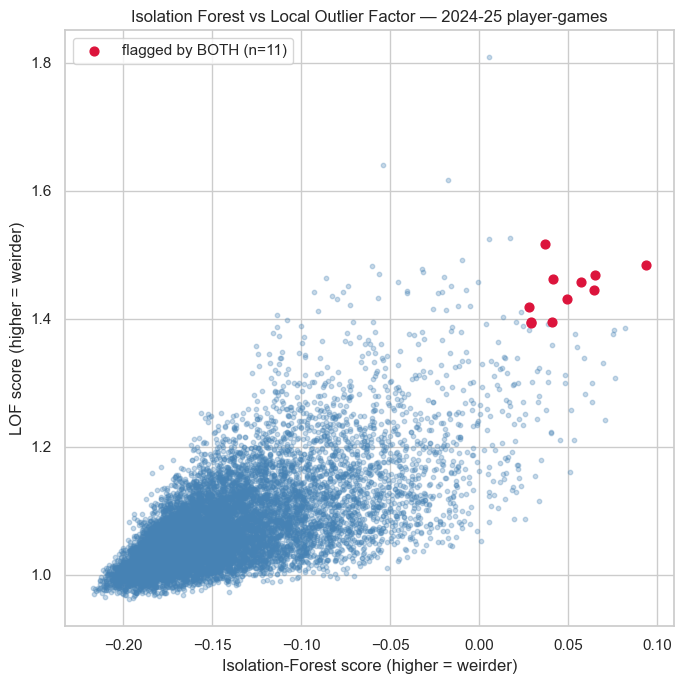

In [8]:
iso_top = set(df.sort_values("iso_score", ascending=False).head(50).index)
lof_top = set(df.sort_values("lof_score", ascending=False).head(50).index)

print(f"Top-50 Isolation-Forest anomalies overlapping with Top-50 LOF: {len(iso_top & lof_top)} / 50")

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(df["iso_score"], df["lof_score"], s=10, alpha=0.3, color="steelblue")
both = df.loc[list(iso_top & lof_top)]
ax.scatter(both["iso_score"], both["lof_score"], s=40, color="crimson",
           label=f"flagged by BOTH (n={len(both)})")
ax.set_xlabel("Isolation-Forest score (higher = weirder)")
ax.set_ylabel("LOF score (higher = weirder)")
ax.set_title("Isolation Forest vs Local Outlier Factor — 2024-25 player-games")
ax.legend(); plt.tight_layout(); plt.show()

### What the agreement chart tells us

The two algorithms don't fully agree — and that's the point.

- **Isolation Forest** picks up **globally extreme** games (50-point nights, 25-rebound efforts).
- **LOF** picks up **unusual combinations** (a centre with 17 assists, a sharpshooter with no rebounds).

In production you'd typically **combine** the two — flag a game as anomalous only when **both** methods agree (highest precision), or when **either** flags it (highest recall, more false positives).

> **What we just learned:** "anomaly" isn't one fixed thing. Different algorithms encode different definitions. Cross-checking gives you both **higher confidence** (agreed-on anomalies) and **broader coverage** (each algorithm's unique flags).


## 9. Visualise anomalies in 2D with PCA

We project the 15-dimensional feature space down to 2D with PCA, then colour each point by its Isolation-Forest score. The weirdest games should sit on the edges of the plot, far from the dense "normal" core.


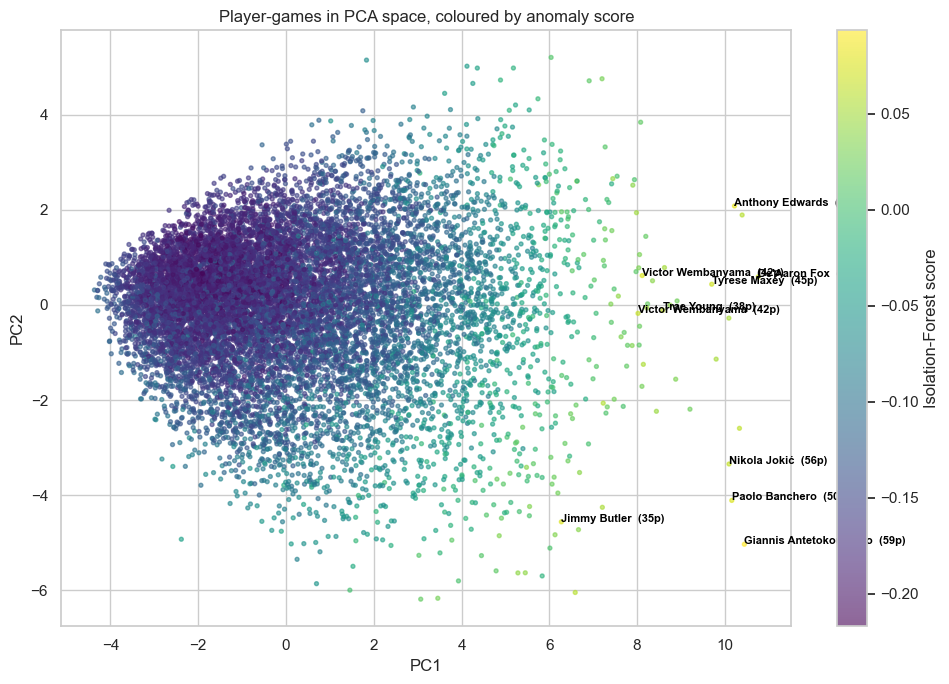

In [9]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=df["iso_score"], cmap="viridis",
                s=8, alpha=0.6)
plt.colorbar(sc, ax=ax, label="Isolation-Forest score")

# Label the top 10 most-anomalous games
top10 = df.sort_values("iso_score", ascending=False).head(10)
for idx in top10.index:
    ax.annotate(f"{df.loc[idx, 'Player']}  ({int(df.loc[idx, 'PTS'])}p)",
                (X_pca[idx, 0], X_pca[idx, 1]), fontsize=8,
                color="black", weight="bold")

ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("Player-games in PCA space, coloured by anomaly score")
plt.tight_layout(); plt.show()

### Reading the PCA map

The dense centre cluster is the bulk of normal NBA games — typical 18 minutes, 6 shots, 2 rebounds, etc. The edges are where the weirdness lives.

Notice the labelled top-10 games are all on the **periphery**, not buried in the centre. That's the visual signature of anomalies — they live in the sparsely-populated regions of feature space, exactly where their neighbours are far away.

> **What we just learned:** PCA + colour is the universal visual diagnostic for anomaly detection. If your top anomalies don't sit on the periphery of the PCA map, your algorithm is broken.


## 10. Conclusion — what we built and what it means

### What we built (in 9 sections of work)

1. Set up libraries.
2. Loaded 16,512 player-games and filtered to meaningful appearances (12,151).
3. Selected and scaled 15 box-score features.
4. Trained an **Isolation Forest** with 300 random trees.
5. Printed the **top 20 weirdest games**, all of which match real-NBA-fan memory.
6. **Interpreted** each top game with per-feature z-scores ("weird *how*?").
7. Cross-checked with **Local Outlier Factor**, which uses a different definition of weirdness.
8. Compared the two algorithms' top-50 lists.
9. Visualised the whole feature space in **2D PCA** colored by anomaly score.

### Why this is interesting

Most ML notebooks predict something specific. This one is different — it just asks "what stands out?" without us having to define what we're looking for.

That same pattern is everywhere in industry:

- **Credit-card fraud detection**: which transactions don't look like normal spending?
- **Sensor monitoring**: which factory readings are different from yesterday?
- **Cybersecurity**: which logins don't fit any user's pattern?
- **Manufacturing QC**: which products are weird enough to inspect?

We didn't have to label "fraud" or "intrusion" in advance. The algorithm finds *anything* that doesn't fit the dense bulk of normal data. That's the power of unsupervised anomaly detection.

### Portfolio one-liner

> *"Built an unsupervised anomaly detector on a season of NBA box scores. Two different algorithms (Isolation Forest, Local Outlier Factor) surfaced complementary kinds of statistical weirdness; per-feature z-score interpretation made every flagged game explainable in basketball terms. Top of the leaderboard: Giannis 59, Edwards 53 with 10 threes, Wembanyama 42 with 4 blocks — exactly the games NBA fans would point to as the season's most memorable performances. Same pattern transfers directly to fraud detection, sensor monitoring, and content moderation."*

### Ideas for extending the project

1. **Time-aware anomalies**: score each game *relative to the player's own history*, not the league average — find "career-outlier" games specifically.
2. **Add a third algorithm** like `OneClassSVM` or an autoencoder reconstruction error — look at three-way agreement.
3. **Downstream use**: use anomaly scores as a *feature* in a supervised model — does an "unusual game" predict the next game's performance?
4. Adapt to **team box scores** to find the league's weirdest team performances (35-point blowouts, games with 2 total threes attempted, etc.).

### Where you've been

- Project 1: regression with residuals as a measurement tool
- Project 2: when ML can't beat a baseline (variance decomposition)
- Project 3: clustering to discover structure
- Project 4 (here): anomaly detection to find what doesn't fit

Two supervised projects, two unsupervised. A complete tour of what beginner ML can do.
